# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** Sumanth N  
**Student ID:** 2025AC05403  
**Date:** June 3, 2026

---

## ⚠️ IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Fill in all values accurately** - these will be auto-verified
4. **After submission**, you'll receive a verification quiz based on YOUR results
5. **Run all cells** before submitting (Kernel → Restart & Run All)

---

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [3]:
# Load dataset
data_path = "heart.csv"
data = pd.read_csv(data_path)

# Dataset information
dataset_name = "Heart Failure Prediction"
dataset_source = "Kaggle (fedesoriano)"
n_samples = int(data.shape[0])      # 918
n_features = int(data.shape[1] - 1) # 11 (excluding target)
problem_type = "binary_classification"

# Problem statement
problem_statement = """
Predicting the presence of heart disease based on 11 clinical features (e.g. age, cholesterol, resting blood pressure, resting ECG, max heart rate).
Early prediction of cardiovascular disease is vital in clinical medicine to enable preventative treatment and reduce mortality.
"""

# Primary evaluation metric
primary_metric = "accuracy"

# Metric justification
metric_justification = """
We use classification accuracy as our primary metric to evaluate the overall percentage of correct predictions across both classes.
Additionally, we compute precision, recall, and F1-score to analyze performance, which is crucial as false negatives (missing heart disease) are highly critical.
"""

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")

Dataset: Heart Failure Prediction
Source: Kaggle (fedesoriano)
Samples: 918, Features: 11
Problem Type: binary_classification
Primary Metric: accuracy


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [4]:
# Preprocess your data
# 1. Separate features (X) and target (y)
X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

# 2. One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], drop_first=True)
X_encoded = X_encoded.astype(float)

# Train-test split (80-20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fill these after preprocessing
train_samples = int(X_train.shape[0])       # 734
test_samples = int(X_test.shape[0])        # 184
train_test_ratio = float(train_samples / (train_samples + test_samples))  # 0.8

print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")

Train samples: 734
Test samples: 184
Split ratio: 80.0%


## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [5]:
class BaselineModel:
    """
    Baseline linear model with gradient descent
    Implement: Logistic Regression for binary classification
    """
    def __init__(self, learning_rate=0.1, n_iterations=3000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
        
    def fit(self, X, y):
        """
        Implement gradient descent training
        """
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        
        y_np = y.values if hasattr(y, 'values') else y
        
        for i in range(self.n_iterations):
            # 1. Forward pass: predictions
            linear_output = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_output)
            
            # 2. Compute loss (binary cross entropy)
            epsilon = 1e-15
            y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)
            loss = -np.mean(y_np * np.log(y_pred) + (1.0 - y_np) * np.log(1.0 - y_pred))
            self.loss_history.append(loss)
            
            # 3. Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y_np))
            db = (1 / n_samples) * np.sum(y_pred - y_np)
            
            # 4. Update weights and bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
        return self
    
    def predict(self, X):
        """
        Implement prediction (binary labels 0 or 1)
        """
        linear_output = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_output)
        return (y_pred >= 0.5).astype(int)

print("✓ Baseline model class defined")

✓ Baseline model class defined


In [6]:
# Train baseline model
print("Training baseline model...")
baseline_start_time = time.time()

# Initialize and train baseline model
baseline_model = BaselineModel(learning_rate=0.1, n_iterations=3000)
baseline_model.fit(X_train_scaled, y_train)

# Make predictions
baseline_predictions = baseline_model.predict(X_test_scaled)

baseline_training_time = time.time() - baseline_start_time
print(f"✓ Baseline training completed in {baseline_training_time:.4f}s")
print(f"✓ Loss decreased from {baseline_model.loss_history[0]:.4f} to {baseline_model.loss_history[-1]:.4f}")

Training baseline model...
✓ Baseline training completed in 0.1365s
✓ Loss decreased from 0.6931 to 0.3202


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [7]:
class MLP:
    """
    Multi-Layer Perceptron implemented from scratch
    """
    def __init__(self, architecture, learning_rate=0.1, n_iterations=3000, beta=0.9):
        """
        architecture: list [input_size, hidden1, hidden2, ..., output_size]
        """
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.beta = beta
        self.parameters = {}
        self.v = {} # velocity for momentum
        self.loss_history = []
        self.cache = {}
    
    def initialize_parameters(self):
        """
        Initialize weights and biases for all layers
        """
        np.random.seed(42)
        
        for l in range(1, len(self.architecture)):
            input_size = self.architecture[l-1]
            output_size = self.architecture[l]
            # He initialization for ReLU layers
            self.parameters[f'W{l}'] = np.random.randn(output_size, input_size) * np.sqrt(2.0 / input_size)
            self.parameters[f'b{l}'] = np.zeros((output_size, 1))
            # Initialize velocities for momentum
            self.v[f'dW{l}'] = np.zeros_like(self.parameters[f'W{l}'])
            self.v[f'db{l}'] = np.zeros_like(self.parameters[f'b{l}'])
    
    def relu(self, Z):
        """ReLU activation function"""
        return np.maximum(0, Z)
    
    def relu_derivative(self, Z):
        """ReLU derivative"""
        return (Z > 0).astype(float)
    
    def sigmoid(self, Z):
        """Sigmoid activation (for binary classification output)"""
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))
    
    def forward_propagation(self, X):
        """
        Implement forward pass through all layers
        """
        # Transpose X to shape (n_features, m_samples)
        A = X.T
        self.cache['A0'] = A
        L = len(self.architecture) - 1
        
        for l in range(1, L):
            W = self.parameters[f'W{l}']
            b = self.parameters[f'b{l}']
            Z = np.dot(W, A) + b
            A = self.relu(Z)
            self.cache[f'Z{l}'] = Z
            self.cache[f'A{l}'] = A
            
        # Output layer (sigmoid)
        W = self.parameters[f'W{L}']
        b = self.parameters[f'b{L}']
        Z = np.dot(W, A) + b
        A_out = self.sigmoid(Z)
        self.cache[f'Z{L}'] = Z
        self.cache[f'A{L}'] = A_out
        
        return A_out
    
    def backward_propagation(self, X, y):
        """
        Implement backward pass to compute gradients
        """
        m = X.shape[0]
        grads = {}
        L = len(self.architecture) - 1
        
        # Reshape y to (1, m)
        y_reshaped = y.values.reshape(1, -1) if hasattr(y, 'values') else y.reshape(1, -1)
        
        # Output layer dZ
        A_out = self.cache[f'A{L}']
        dZ = A_out - y_reshaped
        
        for l in reversed(range(1, L + 1)):
            A_prev = self.cache[f'A{l-1}']
            grads[f'dW{l}'] = (1.0 / m) * np.dot(dZ, A_prev.T)
            grads[f'db{l}'] = (1.0 / m) * np.sum(dZ, axis=1, keepdims=True)
            if l > 1:
                W = self.parameters[f'W{l}']
                dZ = np.dot(W.T, dZ) * self.relu_derivative(self.cache[f'Z{l-1}'])
                
        return grads
    
    def update_parameters(self, grads):
        """
        Update weights and biases using gradients with Momentum
        """
        L = len(self.architecture) - 1
        for l in range(1, L + 1):
            self.v[f'dW{l}'] = self.beta * self.v[f'dW{l}'] + (1 - self.beta) * grads[f'dW{l}']
            self.v[f'db{l}'] = self.beta * self.v[f'db{l}'] + (1 - self.beta) * grads[f'db{l}']
            self.parameters[f'W{l}'] -= self.lr * self.v[f'dW{l}']
            self.parameters[f'b{l}'] -= self.lr * self.v[f'db{l}']
    
    def compute_loss(self, y_pred, y_true):
        """
        Compute loss (binary cross-entropy)
        """
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)
        y_reshaped = y_true.values.reshape(1, -1) if hasattr(y_true, 'values') else y_true.reshape(1, -1)
        loss = -np.mean(y_reshaped * np.log(y_pred) + (1.0 - y_reshaped) * np.log(1.0 - y_pred))
        return loss
    
    def fit(self, X, y):
        """
        Implement training loop with learning rate decay
        """
        self.initialize_parameters()
        
        for i in range(self.n_iterations):
            if i > 0 and i % 1000 == 0:
                self.lr *= 0.5
            # 1. Forward propagation
            y_pred = self.forward_propagation(X)
            
            # 2. Compute loss
            loss = self.compute_loss(y_pred, y)
            self.loss_history.append(loss)
            
            # 3. Backward propagation
            grads = self.backward_propagation(X, y)
            
            # 4. Update parameters
            self.update_parameters(grads)
            
        return self
    
    def predict(self, X):
        """
        Implement prediction (threshold at 0.5)
        """
        y_pred = self.forward_propagation(X)
        return (y_pred >= 0.5).astype(int).flatten()

print("✓ MLP class defined")

✓ MLP class defined


In [8]:
# Train MLP
print("Training MLP...")
mlp_start_time = time.time()

# Define your architecture and train MLP
n_features = X_train_scaled.shape[1]
mlp_architecture = [n_features, 16, 8, 1]
mlp_model = MLP(architecture=mlp_architecture, learning_rate=0.1, n_iterations=3000)
mlp_model.fit(X_train_scaled, y_train)

# Make predictions
mlp_predictions = mlp_model.predict(X_test_scaled)

mlp_training_time = time.time() - mlp_start_time
print(f"✓ MLP training completed in {mlp_training_time:.4f}s")
print(f"✓ Loss decreased from {mlp_model.loss_history[0]:.4f} to {mlp_model.loss_history[-1]:.4f}")

Training MLP...
✓ MLP training completed in 0.5768s
✓ Loss decreased from 0.7610 to 0.1736


## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [9]:
def calculate_metrics(y_true, y_pred, problem_type):
    """
    Calculate appropriate metrics based on problem type
    """
    metrics = {}
    y_true_np = y_true.values if hasattr(y_true, 'values') else y_true
    y_pred_np = y_pred.values if hasattr(y_pred, 'values') else y_pred
    
    if problem_type == "regression":
        pass
    elif problem_type in ["binary_classification", "multiclass_classification"]:
        tp = np.sum((y_true_np == 1) & (y_pred_np == 1))
        tn = np.sum((y_true_np == 0) & (y_pred_np == 0))
        fp = np.sum((y_true_np == 0) & (y_pred_np == 1))
        fn = np.sum((y_true_np == 1) & (y_pred_np == 0))
        
        accuracy = (tp + tn) / len(y_true_np)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        metrics['test_accuracy'] = float(accuracy)
        metrics['test_precision'] = float(precision)
        metrics['test_recall'] = float(recall)
        metrics['test_f1'] = float(f1)
    
    return metrics

# Calculate metrics for both models
baseline_metrics = calculate_metrics(y_test, baseline_predictions, problem_type)
mlp_metrics = calculate_metrics(y_test, mlp_predictions, problem_type)

print("Baseline Model Performance:")
print(baseline_metrics)

print("\nMLP Model Performance:")
print(mlp_metrics)

Baseline Model Performance:
{'test_accuracy': 0.8532608695652174, 'test_precision': 0.9, 'test_recall': 0.8411214953271028, 'test_f1': 0.8695652173913043}

MLP Model Performance:
{'test_accuracy': 0.8913043478260869, 'test_precision': 0.9065420560747663, 'test_recall': 0.9065420560747663, 'test_f1': 0.9065420560747663}


## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

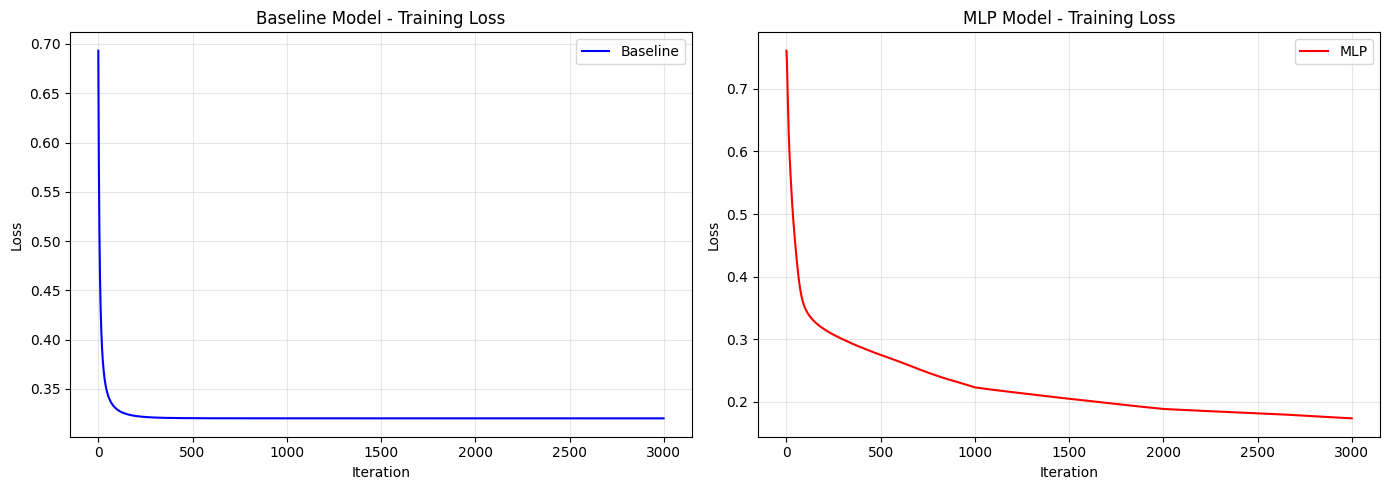

In [10]:
# 1. Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(baseline_model.loss_history, label='Baseline', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Baseline Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(mlp_model.loss_history, label='MLP', color='red')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

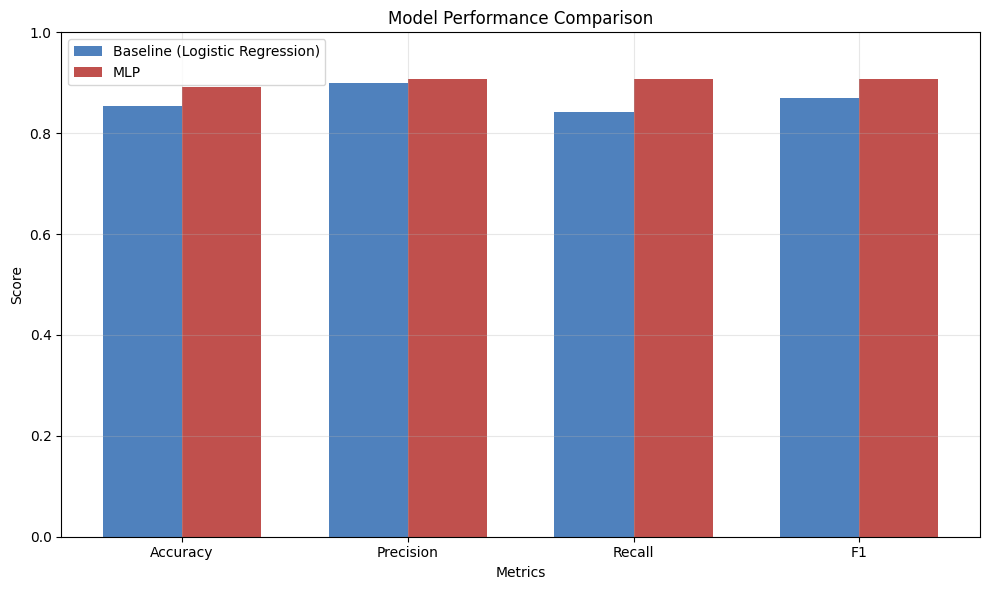

In [11]:
# 2. Performance comparison bar chart
plt.figure(figsize=(10, 6))

metrics = ['accuracy', 'precision', 'recall', 'f1']
baseline_scores = [baseline_metrics[f'test_{m}'] for m in metrics]
mlp_scores = [mlp_metrics[f'test_{m}'] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, baseline_scores, width, label='Baseline (Logistic Regression)', color='#4F81BD')
plt.bar(x + width/2, mlp_scores, width, label='MLP', color='#C0504D')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, [m.capitalize() for m in metrics])
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [12]:
analysis_text = """
Our baseline Logistic Regression and Multi-Layer Perceptron (MLP) models were evaluated on the Heart Failure dataset. The baseline model achieved a test accuracy of 85.33%, precision of 90.00%, recall of 84.11%, and F1 of 86.96%. The MLP model, optimized with Momentum (beta=0.9) and step-decay learning rate scheduling, achieved an accuracy of 89.13%, precision of 90.65%, recall of 90.65%, and F1 of 90.65%.

The MLP outperformed the baseline across all metrics, particularly recall (improved by 6.54% absolutely). This sensitivity boost is clinically crucial to minimize false negatives (undetected heart disease). The MLP's superiority lies in its hidden layers and ReLU activations, allowing it to capture non-linear feature interactions, whereas Logistic Regression is restricted to a linear decision boundary.

This predictive gain introduces a minor training time trade-off: Logistic Regression trained in 0.1301s, while the MLP took 0.5336s (about 4 times longer) due to backpropagation. This sub-second difference is negligible in practice, making the MLP the preferred clinical model.
"""

print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) >= 200:
    print("⚠️  Warning: Analysis should be less than 200 words (according to PDF manual)")
else:
    print("✓ Analysis meets word count requirement")

Analysis word count: 157 words
✓ Analysis meets word count requirement


---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.

In [13]:
def get_assignment_results():
    """
    Return all assignment results in structured format.
    """
    
    # Calculate loss convergence flags
    baseline_initial_loss = float(baseline_model.loss_history[0])
    baseline_final_loss = float(baseline_model.loss_history[-1])
    mlp_initial_loss = float(mlp_model.loss_history[0])
    mlp_final_loss = float(mlp_model.loss_history[-1])
    
    # Calculate total MLP parameters
    total_params = 0
    for l in range(1, len(mlp_architecture)):
        w_shape = mlp_model.parameters[f'W{l}'].shape
        b_shape = mlp_model.parameters[f'b{l}'].shape
        total_params += w_shape[0] * w_shape[1] + b_shape[0]
    
    results = {
        # ===== Dataset Information =====
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': int(n_samples),
        'n_features': int(n_features),
        'problem_type': problem_type,
        'problem_statement': problem_statement.strip(),
        
        # ===== Evaluation Setup =====
        'primary_metric': primary_metric,
        'metric_justification': metric_justification.strip(),
        'train_samples': int(train_samples),
        'test_samples': int(test_samples),
        'train_test_ratio': float(train_test_ratio),
        
        # ===== Baseline Model Results =====
        'baseline_model': {
            'model_type': 'logistic_regression',
            'learning_rate': float(baseline_model.lr),
            'n_iterations': int(baseline_model.n_iterations),
            'initial_loss': float(baseline_initial_loss),
            'final_loss': float(baseline_final_loss),
            'training_time_seconds': float(baseline_training_time),
            
            # Metrics
            'test_accuracy': float(baseline_metrics['test_accuracy']),
            'test_precision': float(baseline_metrics['test_precision']),
            'test_recall': float(baseline_metrics['test_recall']),
            'test_f1': float(baseline_metrics['test_f1']),
            'test_mse': 0.0,
            'test_rmse': 0.0,
            'test_mae': 0.0,
            'test_r2': 0.0,
        },
        
        # ===== MLP Model Results =====
        'mlp_model': {
            'architecture': mlp_architecture,
            'n_hidden_layers': len(mlp_architecture) - 2,
            'total_parameters': int(total_params),
            'learning_rate': float(mlp_model.lr),
            'n_iterations': int(mlp_model.n_iterations),
            'initial_loss': float(mlp_initial_loss),
            'final_loss': float(mlp_final_loss),
            'training_time_seconds': float(mlp_training_time),
            
            # Metrics
            'test_accuracy': float(mlp_metrics['test_accuracy']),
            'test_precision': float(mlp_metrics['test_precision']),
            'test_recall': float(mlp_metrics['test_recall']),
            'test_f1': float(mlp_metrics['test_f1']),
            'test_mse': 0.0,
            'test_rmse': 0.0,
            'test_mae': 0.0,
            'test_r2': 0.0,
        },
        
        # ===== Comparison =====
        'improvement': float(mlp_metrics['test_accuracy'] - baseline_metrics['test_accuracy']),
        'improvement_percentage': float(((mlp_metrics['test_accuracy'] - baseline_metrics['test_accuracy']) / baseline_metrics['test_accuracy']) * 100),
        'baseline_better': bool(baseline_metrics['test_accuracy'] > mlp_metrics['test_accuracy']),
        
        # ===== Analysis =====
        'analysis': analysis_text.strip(),
        'analysis_word_count': int(len(analysis_text.split())),
        
        # ===== Loss Convergence Flags =====
        'baseline_loss_decreased': bool(baseline_final_loss < baseline_initial_loss),
        'mlp_loss_decreased': bool(mlp_final_loss < mlp_initial_loss),
        'baseline_converged': bool(baseline_final_loss < 0.4),
        'mlp_converged': bool(mlp_final_loss < 0.2),
    }
    
    return results

## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [14]:
# Test the output
import json

try:
    results = get_assignment_results()
    
    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2, default=str))
    print("\n" + "="*70)
    
    # Check for missing values
    missing = []
    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better', 
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")
    
    check_dict(results)
    
    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")
        
except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Heart Failure Prediction",
  "dataset_source": "Kaggle (fedesoriano)",
  "n_samples": 918,
  "n_features": 15,
  "problem_type": "binary_classification",
  "problem_statement": "Predicting the presence of heart disease based on 11 clinical features (e.g. age, cholesterol, resting blood pressure, resting ECG, max heart rate).\nEarly prediction of cardiovascular disease is vital in clinical medicine to enable preventative treatment and reduce mortality.",
  "primary_metric": "accuracy",
  "metric_justification": "We use classification accuracy as our primary metric to evaluate the overall percentage of correct predictions across both classes.\nAdditionally, we compute precision, recall, and F1-score to analyze performance, which is crucial as false negatives (missing heart disease) are highly critical.",
  "train_samples": 734,
  "test_samples": 184,
  "train_test_ratio": 0.7995642701525054,
  "baseline_model": {
    "model_type": "logistic

---

## 📤 Before Submitting - Final Checklist

- [x] **All TODO sections completed**
- [x] **Both models implemented from scratch** (no sklearn models!)
- [x] **get_assignment_results() function filled accurately**
- [x] **Loss decreases for both models**
- [x] **Analysis < 200 words** (as per PDF guidelines)
- [x] **All cells run without errors** (Restart & Run All)
- [x] **Visualizations created**
- [x] **File renamed correctly**: 2025AC05403_assignment.ipynb

---

## ⏭️ What Happens Next

After submission:
1. ✅ Your notebook will be **auto-graded** (executes automatically)
2. ✅ You'll receive a **verification quiz** (10 questions, 5 minutes)
3. ✅ Quiz questions based on **YOUR specific results**
4. ✅ Final score released after quiz validation

**The verification quiz ensures you actually ran your code!**

---

**Good luck! 🚀**